# 04_09. Compare scalar Rényi (04_05) and matrix Rényi (04_06) to Tau (04_04)

In [ ]:
print("Hello World")

In [12]:
import logging
logging.getLogger("fontTools").setLevel(logging.WARNING)

import os
_r = os.path.abspath(".")
while _r != os.path.dirname(_r) and not os.path.exists(os.path.join(_r, ".notebooks_root")):
    _r = os.path.dirname(_r)
os.chdir(_r if os.path.exists(os.path.join(_r, ".notebooks_root")) else "/oak/stanford/groups/quake/mmantri/group.quake/tabula_longread/notebooks")  # cd to notebooks/ root (marked .notebooks_root); relocation-proof

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.legend as _mlegend
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import warnings, os
warnings.filterwarnings('ignore')

CSVS_DIR = "./../csvs"
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)
ALPHA = 2
MIN_CELLTYPES = 5   # per-gene aggregates need >= this many cell types

# preferred plot formatting
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial'] + matplotlib.rcParams['font.sans-serif']
# Mathtext (anything in $...$) otherwise falls back to DejaVu Sans, so Greek letters,
# superscripts and subscripts render in a different family from the surrounding Arial.
# "custom" + the four Arial families keeps the whole figure in one typeface.
matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.rm'] = 'Arial'
matplotlib.rcParams['mathtext.it'] = 'Arial:italic'
matplotlib.rcParams['mathtext.bf'] = 'Arial:bold'
TICK_LEN = 2.0
TICK_LABEL_PAD = 1.5
AXIS_LABEL_PAD = 1.5
PANEL_TITLE_PAD = 3.0
plt.rcParams.update({
    "font.size": 6,
    "axes.titlesize": 6,
    "axes.labelsize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "legend.labelspacing": 0.1,
    "legend.borderpad": 0.3,
    "legend.handletextpad": 0.2,
    "legend.title_fontsize": 6,
    "figure.titlesize": 6,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "figure.titleweight": "bold",
    "xtick.major.size": TICK_LEN,
    "ytick.major.size": TICK_LEN,
    "xtick.major.pad": TICK_LABEL_PAD,
    "ytick.major.pad": TICK_LABEL_PAD,
    "axes.labelpad": AXIS_LABEL_PAD,
    "axes.titlepad": PANEL_TITLE_PAD,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

# Legend-title weight has no rcParam -> make every legend title bold by default.
if not getattr(_mlegend.Legend, "_bold_title_patched", False):
    _orig_set_title = _mlegend.Legend.set_title
    def _bold_set_title(self, title, prop=None):
        res = _orig_set_title(self, title, prop=prop)
        self.get_title().set_fontweight("bold")
        return res
    _mlegend.Legend.set_title = _bold_set_title
    _mlegend.Legend._bold_title_patched = True

# --- load the saved metrics ---
tau_df = pd.read_csv(f"{CSVS_DIR}/all_samples_recollapsed_tau_per_gene_celltype.csv")          # gene, cell_ontology_class, tau, n_isoforms, n_cells_expr
renyi_df = pd.read_csv(f"{CSVS_DIR}/per_gene_celltype_isoform_diversity_renyi_H_alpha{ALPHA}.csv")  # gene, cell_ontology_class, entropy, ...
matrix_df = pd.read_csv(f"{CSVS_DIR}/per_gene_matrix_renyi_alpha{ALPHA}.csv")                   # gene, matrix_renyi, n_isoforms, n_celltypes, ...

# The saved metric CSVs still use the column 'popv_prediction', while this notebook references
# 'cell_ontology_class' (column migration). Normalize on load so the merges work either way.
def _std_ct(df):
    if "cell_ontology_class" not in df.columns and "popv_prediction" in df.columns:
        return df.rename(columns={"popv_prediction": "cell_ontology_class"})
    return df
tau_df = _std_ct(tau_df); renyi_df = _std_ct(renyi_df); matrix_df = _std_ct(matrix_df)
print(f"Tau: {tau_df.shape} | scalar Rényi: {renyi_df.shape} | matrix Rényi: {matrix_df.shape}")

# reload figure_paths: a live kernel caches FIG_MAP
import importlib
import figure_paths
importlib.reload(figure_paths)
from figure_paths import figpath  # routes figures/ -> figures/figureN/ via FIG_MAP


Tau: (1013649, 5) | scalar Rényi: (1092139, 6) | matrix Rényi: (20347, 6)


## 1. Scalar Rényi vs 1 − Tau (gene × cell type)

Both are computed from the same per-(gene, cell type) mean isoform-fraction vector. Using **1 − Tau** (evenness/diversity direction, so higher = less specific) puts it on the same polarity as scalar Rényi $H_\alpha$ — expect a **positive** relationship. The scatter is split into **isoform-count bins**, since the two measures agree differently depending on how many isoforms a gene has.

In [13]:
# Merge Tau and scalar Rényi at the (gene, cell type) level; use 1 - Tau (evenness direction)
gc_merge = tau_df.merge(renyi_df[["gene", "cell_ontology_class", "entropy"]],
                        on=["gene", "cell_ontology_class"], how="inner")
gc_merge = gc_merge.rename(columns={"entropy": "renyi"})
gc_merge["one_minus_tau"] = 1.0 - gc_merge["tau"]
print(f"Matched gene x cell-type pairs: {len(gc_merge):,}")

r_p, _ = pearsonr(gc_merge["one_minus_tau"], gc_merge["renyi"])
r_s, _ = spearmanr(gc_merge["one_minus_tau"], gc_merge["renyi"])
print(f"(1 - Tau) vs scalar Rényi: Pearson r = {r_p:.3f}, Spearman ρ = {r_s:.3f}")


Matched gene x cell-type pairs: 1,013,649
(1 - Tau) vs scalar Rényi: Pearson r = 0.367, Spearman ρ = 0.506


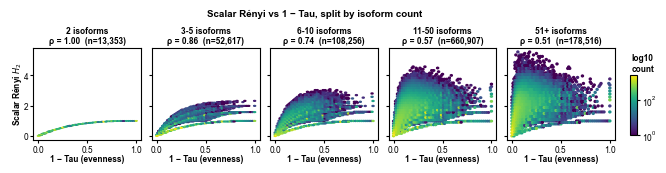

In [14]:
# Scatter split by isoform-count bins (same bins as 04_08)
ISO_BINS = [(2, 2), (3, 5), (6, 10), (11, 50), (51, 1000)]
ISO_LABELS = ["2", "3-5", "6-10", "11-50", "51+"]
fig, axes = plt.subplots(1, len(ISO_BINS), figsize=(7.5, 1.2), sharey=True)
hb = None
for ax, (lo, hi), lab in zip(axes, ISO_BINS, ISO_LABELS):
    sub = gc_merge[(gc_merge["n_isoforms"] >= lo) & (gc_merge["n_isoforms"] <= hi)]
    if len(sub) < 10:
        ax.set_visible(False)
        continue
    hb = ax.hexbin(sub["one_minus_tau"], sub["renyi"], gridsize=50, cmap="viridis", bins="log", mincnt=1)
    rho, _ = spearmanr(sub["one_minus_tau"], sub["renyi"])
    ax.set_title(f"{lab} isoforms\nρ = {rho:.2f}  (n={len(sub):,})", pad=PANEL_TITLE_PAD)
    ax.set_xlabel("1 − Tau (evenness)", labelpad = 0)
axes[0].set_ylabel(f"Scalar Rényi $H_{ALPHA}$", labelpad = 0)
if hb is not None:
    cax = fig.add_axes([0.92, 0.15, 0.01, 0.5])   # [left, bottom, width, height] in figure coords
    cb = fig.colorbar(hb, cax=cax, shrink=0.5)
    cb.set_label("log10\ncount", rotation=0, ha="left", va="bottom", labelpad=-18, y=1.04)
fig.suptitle("Scalar Rényi vs 1 − Tau, split by isoform count", fontsize = 7, y=1.20)

plt.subplots_adjust(wspace = 0.1, right=0.9)
plt.savefig(figpath(f"04_09_scalar_renyi_vs_1minustau_by_isoform.pdf"))
# plt.show()


In [15]:
# Spearman(1 - Tau, scalar Rényi) within isoform-count strata (same bins as 04_08)
ISO_BINS = [(2, 2), (3, 5), (6, 10), (11, 50), (51, 1000)]
ISO_LABELS = ["2", "3-5", "6-10", "11-50", "51+"]
labels, rhos = [], []
for (lo, hi), lab in zip(ISO_BINS, ISO_LABELS):
    sub = gc_merge[(gc_merge["n_isoforms"] >= lo) & (gc_merge["n_isoforms"] <= hi)]
    if len(sub) < 50:
        continue
    rho, _ = spearmanr(sub["one_minus_tau"], sub["renyi"])
    labels.append(lab)
    rhos.append(rho)


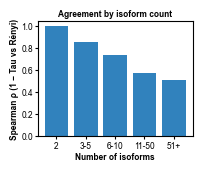

In [16]:
fig, ax = plt.subplots(figsize=(2.0, 1.5))
ax.bar(range(len(rhos)), rhos, color="#3182bd")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_xlabel("Number of isoforms")
ax.set_ylabel("Spearman ρ (1 − Tau vs Rényi)")
ax.set_title("Agreement by isoform count", pad=PANEL_TITLE_PAD)
ax.axhline(0, color="black", lw=0.5)
plt.savefig(figpath(f"04i_1minustau_vs_renyi_spearman_by_isoform.pdf"))
plt.show()


## 2. Within-cell-type matrix Rényi (04_05 §11) vs 1 − Tau (gene × cell type)

04_05 §11 computes a matrix Rényi per (gene, cell type) on the **cells × isoform** matrix within a cell type — capturing **within-cell-type per-cell heterogeneity** (do different cells of the same type use different isoforms). Compare it to **1 − Tau**, the evenness of the cell type's *mean* profile. The two can diverge: an even mean profile (high 1 − Tau) can arise either from every cell mixing isoforms (low within-type rank) **or** from different cells each locking onto a different isoform (high within-type rank), so 1 − Tau is a necessary-but-not-sufficient signal for per-cell heterogeneity. Split by isoform count.

In [17]:
# Within-cell-type matrix Rényi from 04_05 §11 (per gene x cell type)
mat11 = pd.read_csv(f"{CSVS_DIR}/per_gene_celltype_isoform_diversity_matrix_renyi_alpha{ALPHA}.csv")  # gene, cell_ontology_class, matrix_entropy, ...
mat11 = _std_ct(mat11)
gc11 = gc_merge[["gene", "cell_ontology_class", "one_minus_tau", "n_isoforms"]].merge(
    mat11[["gene", "cell_ontology_class", "matrix_entropy"]], on=["gene", "cell_ontology_class"], how="inner")
print(f"Matched gene x cell-type pairs: {len(gc11):,}")

r_p, _ = pearsonr(gc11["one_minus_tau"], gc11["matrix_entropy"])
r_s, _ = spearmanr(gc11["one_minus_tau"], gc11["matrix_entropy"])
print(f"(1 - Tau) vs within-cell-type matrix Rényi: Pearson r = {r_p:.3f}, Spearman ρ = {r_s:.3f}")


Matched gene x cell-type pairs: 1,013,649
(1 - Tau) vs within-cell-type matrix Rényi: Pearson r = 0.381, Spearman ρ = 0.524


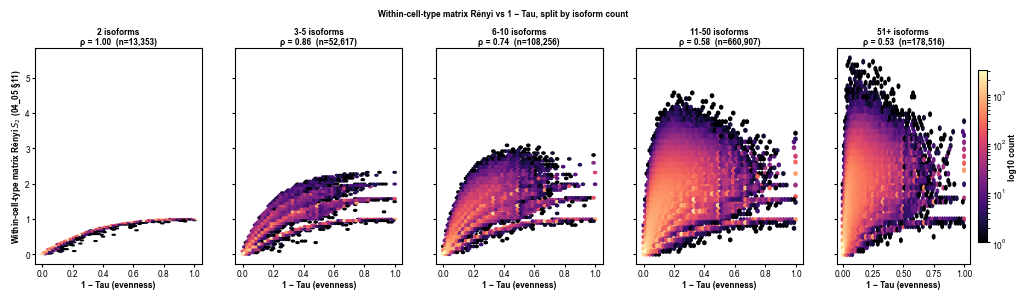

In [18]:
# Scatter split by isoform-count bins (same bins as 04_08)
ISO_BINS = [(2, 2), (3, 5), (6, 10), (11, 50), (51, 1000)]
ISO_LABELS = ["2", "3-5", "6-10", "11-50", "51+"]
fig, axes = plt.subplots(1, len(ISO_BINS), figsize=(2.5 * len(ISO_BINS), 2.8), sharey=True)
hb = None
for ax, (lo, hi), lab in zip(axes, ISO_BINS, ISO_LABELS):
    sub = gc11[(gc11["n_isoforms"] >= lo) & (gc11["n_isoforms"] <= hi)]
    if len(sub) < 10:
        ax.set_visible(False)
        continue
    hb = ax.hexbin(sub["one_minus_tau"], sub["matrix_entropy"], gridsize=50, cmap="magma", bins="log", mincnt=1)
    rho, _ = spearmanr(sub["one_minus_tau"], sub["matrix_entropy"])
    ax.set_title(f"{lab} isoforms\nρ = {rho:.2f}  (n={len(sub):,})", pad=PANEL_TITLE_PAD)
    ax.set_xlabel("1 − Tau (evenness)")
axes[0].set_ylabel(f"Within-cell-type matrix Rényi $S_{ALPHA}$ (04_05 §11)")
if hb is not None:
    fig.colorbar(hb, ax=axes[-1], label="log10 count", shrink=0.8)
fig.suptitle("Within-cell-type matrix Rényi vs 1 − Tau, split by isoform count", y=1.02)
plt.savefig(figpath(f"04_09_matrixrenyi11_vs_1minustau_by_isoform.pdf"))
plt.show()


## 3. Per-gene matrix Rényi (04_06, between-cell-type) vs per-gene Tau / scalar-Rényi summaries

Aggregate the per-(gene, cell type) Tau and scalar Rényi to per-gene **means** and **variances across cell types** (genes with ≥ `MIN_CELLTYPES` cell types), then relate them to the per-gene matrix Rényi $S_\alpha$ from 04_06. Because $S_\alpha$ is meant to measure between-cell-type variation, it should correlate more strongly with the **variance** of Tau / scalar Rényi across cell types than with their means.

In [19]:
# Per-gene means and variances across cell types
per_gene = gc_merge.groupby("gene").agg(
    mean_tau=("tau", "mean"), var_tau=("tau", "var"),
    mean_renyi=("renyi", "mean"), var_renyi=("renyi", "var"),
    n_celltypes=("cell_ontology_class", "nunique"),
    n_isoforms=("n_isoforms", "first"),
).reset_index()
per_gene = per_gene[per_gene["n_celltypes"] >= MIN_CELLTYPES].copy()

# join per-gene matrix Rényi
m = per_gene.merge(matrix_df[["gene", "matrix_renyi"]], on="gene", how="inner")
print(f"Genes with matrix Rényi + >= {MIN_CELLTYPES} cell types: {len(m):,}")

targets = [("var_tau", "Var(Tau) across cell types"),
           ("mean_tau", "Mean Tau across cell types"),
           ("var_renyi", "Var(scalar Rényi) across cell types"),
           ("mean_renyi", "Mean scalar Rényi across cell types")]

corr_rows = []
for col, lab in targets:
    sub = m[[col, "matrix_renyi", "n_isoforms"]].dropna()
    rho, _ = spearmanr(sub[col], sub["matrix_renyi"])
    corr_rows.append({"vs": col, "spearman_rho": rho})

corr = pd.DataFrame(corr_rows)
print("\nSpearman correlation of per-gene matrix Rényi with each Tau/Rényi summary:")
print(corr.to_string(index=False))
print("\n-> matrix Rényi tracks between-cell-type VARIANCE more than the means if "
      "var_* correlations exceed mean_* correlations.")

# save the merged per-gene table
_out = f"{CSVS_DIR}/renyi_matrix_vs_tau_per_gene.csv"
m.to_csv(_out, index=False)
print(f"\nSaved {len(m)} genes to {_out}")


Genes with matrix Rényi + >= 5 cell types: 19,447

Spearman correlation of per-gene matrix Rényi with each Tau/Rényi summary:
        vs  spearman_rho
   var_tau      0.504935
  mean_tau     -0.710322
 var_renyi      0.634073
mean_renyi      0.796286

-> matrix Rényi tracks between-cell-type VARIANCE more than the means if var_* correlations exceed mean_* correlations.

Saved 19447 genes to ./../csvs/renyi_matrix_vs_tau_per_gene.csv


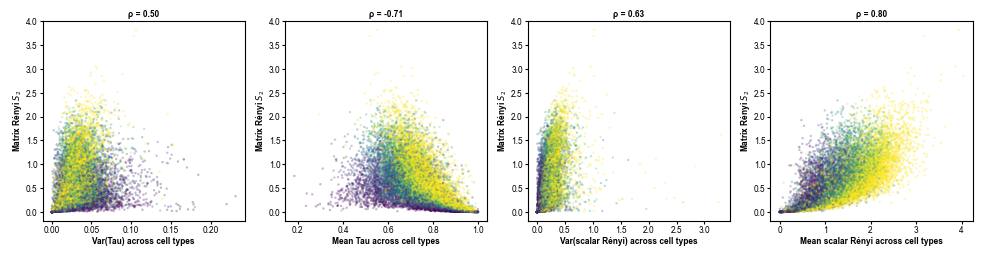

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(12, 2.6))
for ax, (col, lab) in zip(axes, targets):
    sub = m[[col, "matrix_renyi", "n_isoforms"]].dropna()
    rho, _ = spearmanr(sub[col], sub["matrix_renyi"])
    ax.scatter(sub[col], sub["matrix_renyi"], s=3, alpha=0.3, edgecolors="none",
               c=sub["n_isoforms"].clip(upper=20), cmap="viridis")
    ax.set_xlabel(lab)
    ax.set_ylabel(f"Matrix Rényi $S_{ALPHA}$")
    ax.set_title(f"ρ = {rho:.2f}", pad=PANEL_TITLE_PAD)

plt.savefig(figpath(f"04_09_matrix_renyi_vs_tau_summaries.pdf"))
plt.show()


## 4. Scalar Rényi vs Shannon (04_02), normalized Shannon (04_03), and Tau (04_04)

Compare the scalar Rényi entropy ($H_2$) to the other per-(gene, cell type) diversity metrics: Shannon entropy $H$ (04_02), normalized Shannon / Pielou's $J = H/\log_2 N$ (04_03), and $1-\text{Tau}$ (04_04, evenness direction). Normalized Shannon is derived from the saved Shannon table.

In [21]:
# Compare scalar Rényi (04_05) to Shannon (04_02), normalized Shannon / Pielou's J (04_03),
# and Tau (04_04), all at the (gene, cell type) level.
shannon_df = pd.read_csv(f"{CSVS_DIR}/per_gene_celltype_isoform_diversity_shannon_H.csv")  # gene, cell_ontology_class, entropy, n_isoforms, n_cells_expr
shannon_df = _std_ct(shannon_df)
shannon_df = shannon_df.rename(columns={"entropy": "shannon"})
# Normalized Shannon (04_03, Pielou's J) = H / log2(n_isoforms); tables are filtered to n_isoforms >= 2.
shannon_df["norm_shannon"] = shannon_df["shannon"] / np.log2(shannon_df["n_isoforms"])

# Merge all metrics on (gene, cell type)
cmp = (renyi_df[["gene", "cell_ontology_class", "entropy", "n_isoforms"]].rename(columns={"entropy": "renyi"})
       .merge(shannon_df[["gene", "cell_ontology_class", "shannon", "norm_shannon"]],
              on=["gene", "cell_ontology_class"], how="inner")
       .merge(tau_df[["gene", "cell_ontology_class", "tau"]], on=["gene", "cell_ontology_class"], how="inner"))
cmp["one_minus_tau"] = 1.0 - cmp["tau"]
print(f"Matched gene x cell-type pairs across all four metrics: {len(cmp):,}")

# --- Pairwise correlation matrix among all four metrics ---
metrics = cmp[["renyi", "shannon", "norm_shannon", "one_minus_tau"]].rename(columns={
    "renyi": "Rényi H2", "shannon": "Shannon H",
    "norm_shannon": "Norm Shannon J", "one_minus_tau": "1 - Tau"})
print("\nPearson correlation matrix:")
print(metrics.corr(method="pearson").round(3).to_string())
print("\nSpearman correlation matrix:")
print(metrics.corr(method="spearman").round(3).to_string())

# Save the merged per-(gene, cell type) metric table
cmp.to_csv(f"{CSVS_DIR}/04i_renyi_vs_shannon_normshannon_tau_per_gene_celltype.csv", index=False)
print(f"\nSaved merged metric table: {len(cmp):,} rows")


Matched gene x cell-type pairs across all four metrics: 1,013,649

Pearson correlation matrix:
                Rényi H2  Shannon H  Norm Shannon J  1 - Tau
Rényi H2           1.000      0.968           0.770    0.367
Shannon H          0.968      1.000           0.747    0.181
Norm Shannon J     0.770      0.747           1.000    0.370
1 - Tau            0.367      0.181           0.370    1.000

Spearman correlation matrix:
                Rényi H2  Shannon H  Norm Shannon J  1 - Tau
Rényi H2           1.000      0.968           0.822    0.506
Shannon H          0.968      1.000           0.799    0.309
Norm Shannon J     0.822      0.799           1.000    0.460
1 - Tau            0.506      0.309           0.460    1.000

Saved merged metric table: 1,013,649 rows


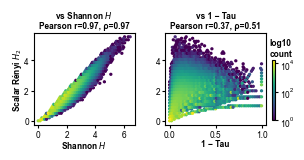

In [19]:
# --- Scatter: scalar Rényi vs Shannon H and 1 - Tau ---
# Normalized Shannon (Pielou's J) dropped from the figure: it is H rescaled by
# log2(n_isoforms), so it carried no comparison the H panel does not already make.
# It is still computed and kept in the correlation matrices / saved CSV in the cell above.
comparisons = [
    ("shannon", "Shannon $H$"),
    ("one_minus_tau", "1 − Tau"),
]
fig, axes = plt.subplots(1, 2, figsize=(3.0, 1.2))
hb = None
for ax, (col, lab) in zip(axes, comparisons):
    hb = ax.hexbin(cmp[col], cmp["renyi"], gridsize=50, cmap="viridis", bins="log", mincnt=1)
    r_p, _ = pearsonr(cmp[col], cmp["renyi"])
    r_s, _ = spearmanr(cmp[col], cmp["renyi"])
    ax.set_title(f"vs {lab}\nPearson r={r_p:.2f}, ρ={r_s:.2f}", pad=PANEL_TITLE_PAD)
    ax.set_xlabel(lab, labelpad = 0.1)
axes[0].set_ylabel(f"Scalar Rényi $H_{ALPHA}$", labelpad = 0.1)
if hb is not None:
    cax = fig.add_axes([0.92, 0.15, 0.01, 0.5])   # [left, bottom, width, height] in figure coords
    cb = fig.colorbar(hb, cax=cax, shrink=0.5)
    cb.set_label("log10\ncount", rotation=0, ha="left", va="bottom",
                 labelpad=-18, y=1.04)
plt.subplots_adjust(wspace = 0.3)
# fig.suptitle("Scalar Rényi vs Shannon and Tau (gene × cell type)", y=1.10)
plt.savefig(figpath(f"04_09_renyi_vs_shannon_normshannon_tau.pdf"))
plt.show()
